# Comparación de Métricas Intrínsecas: 6 Técnicas de Tokenización

Evalúa las 6 técnicas sin tareas downstream usando métricas de:
- Chiarot & Silvestri 2022 (Compression, MSE)
- CAMEO 2025 (ACF Retention)
- Uzan et al. 2024 (Vocabulary Entropy, Bigram Entropy)
- Run-length encoding (Token Persistence)
- Zipf's law (Top-K Coverage)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from tecnicas.discretization import sax_discretize, decode_sax
from tecnicas.text_based import text_based_tokenize, decode_text_based
from tecnicas.patching import patching_tokenize
from tecnicas.decomposition import decomposition_tokenize
from tecnicas.foundation import foundation_tokenize, reconstruct_from_patches, apply_masking
from tecnicas.metrics import evaluate_tokenization
from hmm import baum_welch, viterbi_decode

plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

In [2]:
# Cargar ETTh1
df = pd.read_csv('../dataset/ETT-small/ETTh1.csv')
serie = df['OT'].values[:5000]
T = len(serie)

# Normalizar para comparación justa
mean_orig, std_orig = serie.mean(), serie.std()
serie_norm = (serie - mean_orig) / std_orig

print(f"Serie: T={T}, mean={mean_orig:.2f}, std={std_orig:.2f}")

Serie: T=5000, mean=19.84, std=10.37


In [3]:
resultados = {}

# 1. Discretización (ej: SAX)
sax_result = sax_discretize(serie_norm, alphabet_size=8)
sax_recon = decode_sax(sax_result['tokens'], sax_result['breakpoints'])
resultados['Discretización'] = {
    'vocab_size': sax_result['vocabulary_size'],
    'num_tokens': sax_result['num_tokens'],
    'reconstructed': sax_recon,
    'tokens': sax_result['tokens']
}

# 2. Text-based (ej: LLMTime)
llm_result = text_based_tokenize(serie_norm, precision=2)
llm_recon = decode_text_based(llm_result['text'])
resultados['Text-based'] = {
    'vocab_size': llm_result['vocabulary_size'],
    'num_tokens': len(llm_result['text']),
    'reconstructed': llm_recon,
    'tokens': None
}

# 3. Patching (ej: PatchTST)
patch_len, stride = 16, 16
patches = patching_tokenize(serie_norm, patch_len=patch_len, stride=stride)
patch_recon = patches.flatten()[:T]
if len(patch_recon) < T:
    patch_recon = np.pad(patch_recon, (0, T - len(patch_recon)))
resultados['Patching'] = {
    'vocab_size': np.inf,
    'num_tokens': patches.shape[0],
    'reconstructed': patch_recon,
    'tokens': None
}

# 4. Descomposición (ej: DLinear, Autoformer)
decomp = decomposition_tokenize(serie_norm, kernel_size=25)
decomp_recon = decomp['trend'] + decomp['seasonal']
resultados['Descomposición'] = {
    'vocab_size': 2,
    'num_tokens': 2,
    'reconstructed': decomp_recon,
    'tokens': None
}

# 5. Foundation (ej: MOMENT, mask_ratio=0.3)
moment = foundation_tokenize(serie_norm, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
masked_patches = apply_masking(moment['patches'], moment['mask'], mask_value=0.0)
moment_recon = reconstruct_from_patches(masked_patches, 16, 16, T)
resultados['Foundation'] = {
    'vocab_size': np.inf,
    'num_tokens': moment['num_patches'],
    'reconstructed': moment_recon,
    'tokens': None
}

# 6. HMM (RITMO)
K = 5
params = baum_welch(serie_norm, K=K, max_iter=50, epsilon=1e-4, verbose=False)
states, _ = viterbi_decode(serie_norm, params['A'], params['pi'], params['mu'], params['sigma'])
hmm_recon = params['mu'][states]
resultados['HMM'] = {
    'vocab_size': K,
    'num_tokens': T,
    'reconstructed': hmm_recon,
    'tokens': states
}

print("Técnicas aplicadas:", list(resultados.keys()))
print(f"\n{'Técnica':<16} {'Vocab':<12} {'Num Tokens':<12}")
print("-" * 40)
for nombre, data in resultados.items():
    vocab = data['vocab_size'] if data['vocab_size'] != np.inf else "inf"
    print(f"{nombre:<16} {str(vocab):<12} {data['num_tokens']:<12}")

Técnicas aplicadas: ['Discretización', 'Text-based', 'Patching', 'Descomposición', 'Foundation', 'HMM']

Técnica          Vocab        Num Tokens  
----------------------------------------
Discretización   8            5000        
Text-based       13           52689       
Patching         inf          312         
Descomposición   2            2           
Foundation       inf          312         
HMM              5            5000        


In [4]:
# Calcular métricas intrínsecas con evaluate_tokenization()
metricas = []
for nombre, data in resultados.items():
    m = evaluate_tokenization(
        original=serie_norm,
        reconstructed=data['reconstructed'],
        num_tokens=data['num_tokens'],
        tokens=data['tokens']
    )
    m['Técnica'] = nombre
    m['Vocab_Size'] = data['vocab_size'] if data['vocab_size'] != np.inf else 'inf'
    metricas.append(m)

df_metricas = pd.DataFrame(metricas)
df_metricas = df_metricas[['Técnica', 'Vocab_Size', 'compression_ratio', 'mse_reconstruction', 
                           'acf_retention', 'vocabulary_entropy', 'bigram_entropy', 
                           'token_persistence', 'top_k_coverage']]

print("=" * 80)
print("MÉTRICAS INTRÍNSECAS - 6 TÉCNICAS DE TOKENIZACIÓN")
print("=" * 80)
print("\nMétricas universales (todas las técnicas):")
print("  - compression_ratio: Eficiencia de compresión")
print("  - mse_reconstruction: Pérdida de información")
print("  - acf_retention: Preservación de dependencias temporales")
print("\nMétricas discretas (solo Discretización y HMM):")
print("  - vocabulary_entropy: Distribución de tokens")
print("  - bigram_entropy: Entropía de transiciones")
print("  - token_persistence: Longitud media de runs")
print("  - top_k_coverage: Concentración top-5 tokens")
print("\n" + df_metricas.to_string(index=False))

MÉTRICAS INTRÍNSECAS - 6 TÉCNICAS DE TOKENIZACIÓN

Métricas universales (todas las técnicas):
  - compression_ratio: Eficiencia de compresión
  - mse_reconstruction: Pérdida de información
  - acf_retention: Preservación de dependencias temporales

Métricas discretas (solo Discretización y HMM):
  - vocabulary_entropy: Distribución de tokens
  - bigram_entropy: Entropía de transiciones
  - token_persistence: Longitud media de runs
  - top_k_coverage: Concentración top-5 tokens

       Técnica Vocab_Size  compression_ratio  mse_reconstruction  acf_retention  vocabulary_entropy  bigram_entropy  token_persistence  top_k_coverage
Discretización          8           1.000000        1.699857e-01       0.984905            0.986654        0.756756           6.821282           0.711
    Text-based         13           0.094896        4.060440e-05       1.000000                 NaN             NaN                NaN             NaN
      Patching        inf          16.025641        2.874348e-03

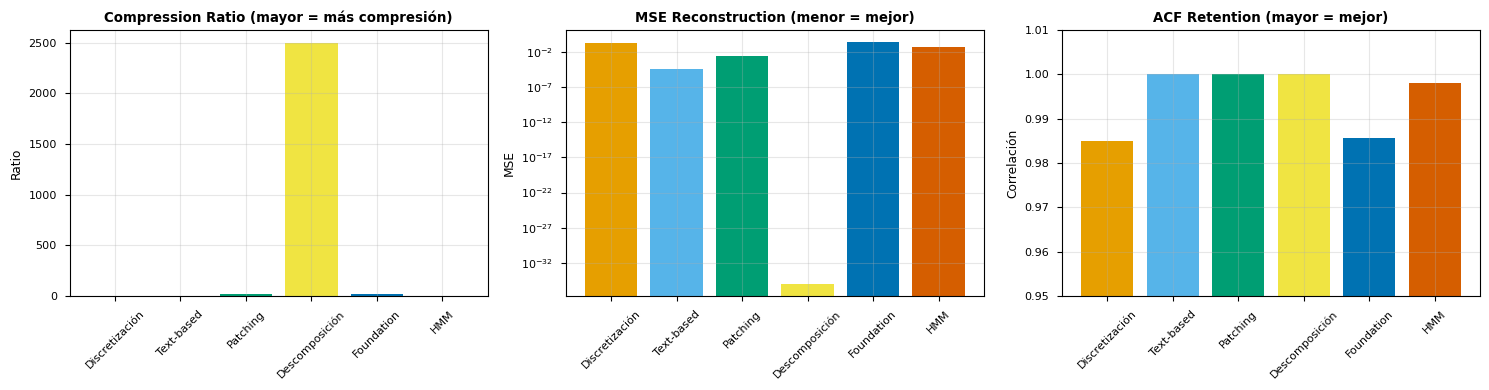

In [5]:
# Visualización de métricas universales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tecnicas = df_metricas['Técnica'].values
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00']

# Compression Ratio
ax = axes[0]
ax.bar(tecnicas, df_metricas['compression_ratio'], color=colors)
ax.set_title('Compression Ratio (mayor = más compresión)', fontweight='bold')
ax.set_ylabel('Ratio')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

# MSE Reconstruction
ax = axes[1]
ax.bar(tecnicas, df_metricas['mse_reconstruction'], color=colors)
ax.set_title('MSE Reconstruction (menor = mejor)', fontweight='bold')
ax.set_ylabel('MSE')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')
ax.grid(alpha=0.3)

# ACF Retention
ax = axes[2]
ax.bar(tecnicas, df_metricas['acf_retention'], color=colors)
ax.set_title('ACF Retention (mayor = mejor)', fontweight='bold')
ax.set_ylabel('Correlación')
ax.set_ylim(0.95, 1.01)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/metricas_universales.png')
plt.show()

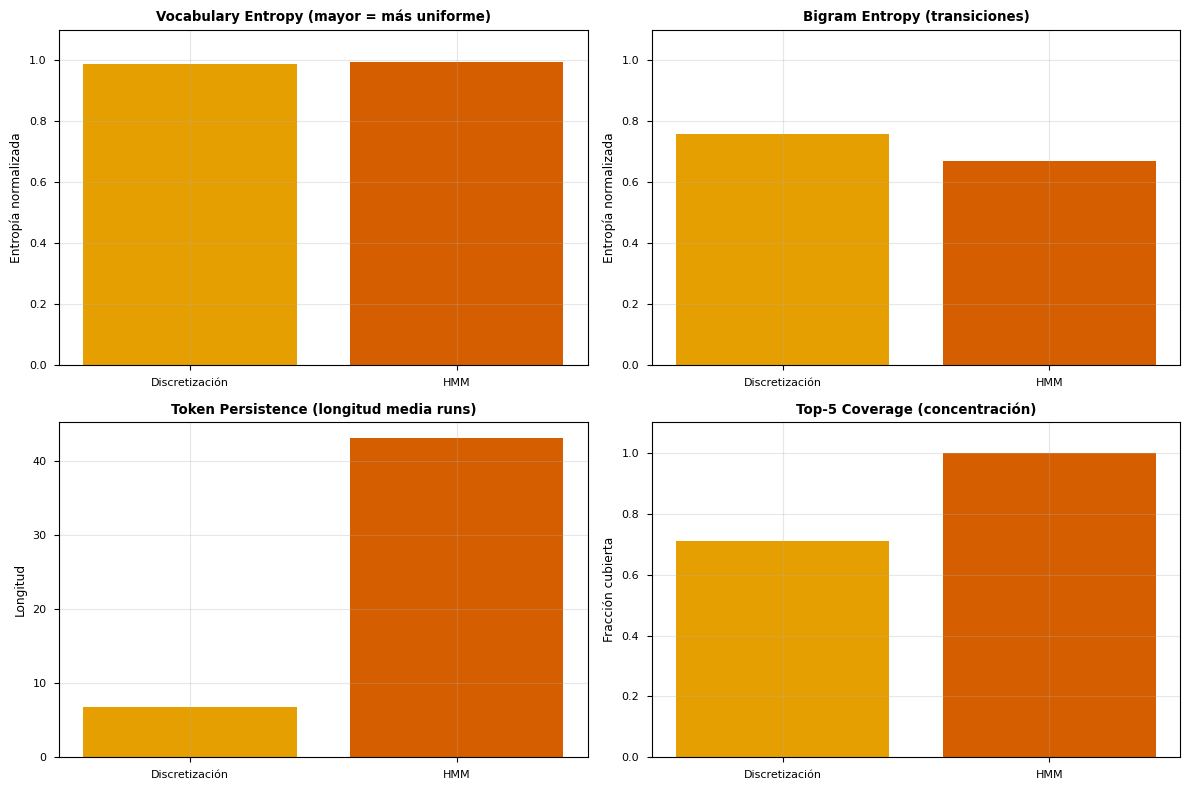

In [6]:
# Visualización de métricas discretas
df_discretas = df_metricas[df_metricas['vocabulary_entropy'].notna()].copy()

if len(df_discretas) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    tecnicas_disc = df_discretas['Técnica'].values
    colors_disc = ['#E69F00', '#D55E00']
    
    # Vocabulary Entropy
    ax = axes[0, 0]
    ax.bar(tecnicas_disc, df_discretas['vocabulary_entropy'], color=colors_disc)
    ax.set_title('Vocabulary Entropy (mayor = más uniforme)', fontweight='bold')
    ax.set_ylabel('Entropía normalizada')
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3)
    
    # Bigram Entropy
    ax = axes[0, 1]
    ax.bar(tecnicas_disc, df_discretas['bigram_entropy'], color=colors_disc)
    ax.set_title('Bigram Entropy (transiciones)', fontweight='bold')
    ax.set_ylabel('Entropía normalizada')
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3)
    
    # Token Persistence
    ax = axes[1, 0]
    ax.bar(tecnicas_disc, df_discretas['token_persistence'], color=colors_disc)
    ax.set_title('Token Persistence (longitud media runs)', fontweight='bold')
    ax.set_ylabel('Longitud')
    ax.grid(alpha=0.3)
    
    # Top-K Coverage
    ax = axes[1, 1]
    ax.bar(tecnicas_disc, df_discretas['top_k_coverage'], color=colors_disc)
    ax.set_title('Top-5 Coverage (concentración)', fontweight='bold')
    ax.set_ylabel('Fracción cubierta')
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/metricas_discretas.png')
    plt.show()

In [7]:
# Resumen ejecutivo
print("=" * 80)
print("RESUMEN EJECUTIVO")
print("=" * 80)

print("\n1. COMPACIDAD/GRANULARIDAD:")
print(f"   Mejor compresión: {df_metricas.loc[df_metricas['compression_ratio'].idxmax(), 'Técnica']} "
      f"({df_metricas['compression_ratio'].max():.2f}x)")

print("\n2. RECONSTRUCCIÓN:")
print(f"   Menor pérdida: {df_metricas.loc[df_metricas['mse_reconstruction'].idxmin(), 'Técnica']} "
      f"(MSE={df_metricas['mse_reconstruction'].min():.2e})")

print("\n3. DEPENDENCIAS TEMPORALES:")
print(f"   Mejor preservación: {df_metricas.loc[df_metricas['acf_retention'].idxmax(), 'Técnica']} "
      f"(ACF={df_metricas['acf_retention'].max():.4f})")

if len(df_discretas) > 0:
    print("\n4. DISTRIBUCIÓN (solo discretas):")
    print(f"   Más uniforme: {df_discretas.loc[df_discretas['vocabulary_entropy'].idxmax(), 'Técnica']} "
          f"(H={df_discretas['vocabulary_entropy'].max():.4f})")
    print(f"   Mayor persistencia: {df_discretas.loc[df_discretas['token_persistence'].idxmax(), 'Técnica']} "
          f"(Run={df_discretas['token_persistence'].max():.2f})")

print("\n" + "=" * 80)
print("NOTA: Estas métricas intrínsecas complementan las métricas downstream (forecasting).")
print("      La evaluación principal del TFG será MSE/MAE en predicción a largo plazo.")
print("=" * 80)

RESUMEN EJECUTIVO

1. COMPACIDAD/GRANULARIDAD:
   Mejor compresión: Descomposición (2500.00x)

2. RECONSTRUCCIÓN:
   Menor pérdida: Descomposición (MSE=1.01e-35)

3. DEPENDENCIAS TEMPORALES:
   Mejor preservación: Descomposición (ACF=1.0000)

4. DISTRIBUCIÓN (solo discretas):
   Más uniforme: HMM (H=0.9944)
   Mayor persistencia: HMM (Run=43.10)

NOTA: Estas métricas intrínsecas complementan las métricas downstream (forecasting).
      La evaluación principal del TFG será MSE/MAE en predicción a largo plazo.


## Métricas de Robustez

Versión ligera: 2 niveles de ruido (0.1σ, 0.5σ), 3 repeticiones por nivel.
- **Perturbation stability**: cambio relativo en MSE y ACF tras añadir ruido
- **Token distance**: edit distance normalizada (discretas) o L2 media (continuas)

In [8]:
from tecnicas.metrics import perturbation_stability, edit_distance_normalized, token_distance_continuous

# Pipelines tokenizar+reconstruir para cada técnica
def sax_pipeline(s):
    r = sax_discretize(s, alphabet_size=8)
    return decode_sax(r['tokens'], r['breakpoints'])

def text_pipeline(s):
    r = text_based_tokenize(s, precision=2)
    return decode_text_based(r['text'])

def patch_pipeline(s):
    p = patching_tokenize(s, patch_len=16, stride=16)
    recon = p.flatten()[:len(s)]
    if len(recon) < len(s):
        recon = np.pad(recon, (0, len(s) - len(recon)))
    return recon

def decomp_pipeline(s):
    d = decomposition_tokenize(s, kernel_size=25)
    return d['trend'] + d['seasonal']

def foundation_pipeline(s):
    f = foundation_tokenize(s, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)
    masked = apply_masking(f['patches'], f['mask'], mask_value=0.0)
    return reconstruct_from_patches(masked, 16, 16, len(s))

def hmm_pipeline(s):
    p = baum_welch(s, K=5, max_iter=50, epsilon=1e-4, verbose=False)
    st, _ = viterbi_decode(s, p['A'], p['pi'], p['mu'], p['sigma'])
    return p['mu'][st]

pipelines = {
    'Discretización': sax_pipeline,
    'Text-based': text_pipeline,
    'Patching': patch_pipeline,
    'Descomposición': decomp_pipeline,
    'Foundation': foundation_pipeline,
    'HMM': hmm_pipeline,
}

# Subconjunto 20% para versión ligera
subset = serie_norm[:1000]
print(f"Subconjunto para robustez: T={len(subset)} (20% de {T})")

# Perturbation stability para cada técnica
robustez = {}
for nombre, pipe in pipelines.items():
    print(f"  {nombre}...", end=" ", flush=True)
    robustez[nombre] = perturbation_stability(
        subset, pipe, noise_levels=[0.1, 0.5], n_reps=3, random_seed=42
    )
    print(f"OK (baseline MSE={robustez[nombre]['baseline_mse']:.4f})")

Subconjunto para robustez: T=1000 (20% de 5000)
  Discretización... OK (baseline MSE=2.0965)
  Text-based... OK (baseline MSE=0.0000)
  Patching... OK (baseline MSE=0.0106)
  Descomposición... OK (baseline MSE=0.0000)
  Foundation... OK (baseline MSE=0.5704)
  HMM... OK (baseline MSE=0.0281)


In [9]:
# Tabla de perturbation stability
rows = []
for nombre, r in robustez.items():
    rows.append({
        'Técnica': nombre,
        'Baseline MSE': r['baseline_mse'],
        'Baseline ACF': r['baseline_acf'],
        'MSE Δ 0.1σ': r['by_level'][0.1]['mse_change_rel'],
        'MSE Δ 0.5σ': r['by_level'][0.5]['mse_change_rel'],
        'ACF Δ 0.1σ': r['by_level'][0.1]['acf_change_rel'],
        'ACF Δ 0.5σ': r['by_level'][0.5]['acf_change_rel'],
    })

df_robustez = pd.DataFrame(rows)
print("PERTURBATION STABILITY - Cambio relativo en MSE y ACF tras ruido gaussiano")
print("=" * 90)
for _, row in df_robustez.iterrows():
    print(f"{row['Técnica']:<16} "
          f"MSE base={row['Baseline MSE']:.4f}  "
          f"Δ0.1σ={row['MSE Δ 0.1σ']:+.2%}  Δ0.5σ={row['MSE Δ 0.5σ']:+.2%}  |  "
          f"ACF base={row['Baseline ACF']:.4f}  "
          f"Δ0.1σ={row['ACF Δ 0.1σ']:+.4%}  Δ0.5σ={row['ACF Δ 0.5σ']:+.4%}")

PERTURBATION STABILITY - Cambio relativo en MSE y ACF tras ruido gaussiano
Discretización   MSE base=2.0965  Δ0.1σ=+0.01%  Δ0.5σ=-0.20%  |  ACF base=0.9868  Δ0.1σ=+0.1655%  Δ0.5σ=+0.5489%
Text-based       MSE base=0.0000  Δ0.1σ=+7.61%  Δ0.5σ=+4.73%  |  ACF base=1.0000  Δ0.1σ=-0.0002%  Δ0.5σ=-0.0002%
Patching         MSE base=0.0106  Δ0.1σ=-0.06%  Δ0.5σ=+7.12%  |  ACF base=0.9996  Δ0.1σ=-0.0012%  Δ0.5σ=-0.1104%
Descomposición   MSE base=0.0000  Δ0.1σ=+6.96%  Δ0.5σ=+13.59%  |  ACF base=1.0000  Δ0.1σ=-0.0000%  Δ0.5σ=+0.0000%
Foundation       MSE base=0.5704  Δ0.1σ=+0.14%  Δ0.5σ=+2.38%  |  ACF base=0.9694  Δ0.1σ=-0.1172%  Δ0.5σ=-7.8975%
HMM              MSE base=0.0281  Δ0.1σ=+1.07%  Δ0.5σ=+198.97%  |  ACF base=0.9930  Δ0.1σ=+0.0256%  Δ0.5σ=-12.2476%


In [10]:
# Distancias intra-técnica: original vs perturbada (noise=0.5σ)
rng = np.random.RandomState(42)
noisy_subset = subset + rng.normal(0, 0.5 * subset.std(), len(subset))

# Discretas: edit distance normalizada
sax_orig = sax_discretize(subset, alphabet_size=8)['tokens']
sax_pert = sax_discretize(noisy_subset, alphabet_size=8)['tokens']
ed_sax = edit_distance_normalized(sax_orig, sax_pert)

hmm_p_orig = baum_welch(subset, K=5, max_iter=50, epsilon=1e-4, verbose=False)
hmm_st_orig, _ = viterbi_decode(subset, hmm_p_orig['A'], hmm_p_orig['pi'], hmm_p_orig['mu'], hmm_p_orig['sigma'])
hmm_p_pert = baum_welch(noisy_subset, K=5, max_iter=50, epsilon=1e-4, verbose=False)
hmm_st_pert, _ = viterbi_decode(noisy_subset, hmm_p_pert['A'], hmm_p_pert['pi'], hmm_p_pert['mu'], hmm_p_pert['sigma'])
ed_hmm = edit_distance_normalized(hmm_st_orig, hmm_st_pert)

# Continuas: L2 media en espacio de tokens
patches_orig = patching_tokenize(subset, patch_len=16, stride=16)
patches_pert = patching_tokenize(noisy_subset, patch_len=16, stride=16)
l2_patch = token_distance_continuous(patches_orig, patches_pert, metric='l2')

decomp_orig = decomposition_tokenize(subset, kernel_size=25)
decomp_pert = decomposition_tokenize(noisy_subset, kernel_size=25)
decomp_tok_orig = np.stack([decomp_orig['trend'], decomp_orig['seasonal']])
decomp_tok_pert = np.stack([decomp_pert['trend'], decomp_pert['seasonal']])
l2_decomp = token_distance_continuous(decomp_tok_orig, decomp_tok_pert, metric='l2')

found_orig = foundation_tokenize(subset, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)['patches']
found_pert = foundation_tokenize(noisy_subset, patch_len=16, stride=16, mask_ratio=0.3, random_seed=42)['patches']
l2_found = token_distance_continuous(found_orig, found_pert, metric='l2')

text_recon_orig = decode_text_based(text_based_tokenize(subset, precision=2)['text'])
text_recon_pert = decode_text_based(text_based_tokenize(noisy_subset, precision=2)['text'])
min_len = min(len(text_recon_orig), len(text_recon_pert))
l2_text = np.sqrt(np.mean((text_recon_orig[:min_len] - text_recon_pert[:min_len])**2))

print("TOKEN DISTANCE INTRA-TÉCNICA (original vs perturbada, noise=0.5σ)")
print("=" * 60)
print(f"\nDiscreta (edit distance normalizada [0,1]):")
print(f"  Discretización (SAX): {ed_sax:.4f}")
print(f"  HMM:                  {ed_hmm:.4f}")
print(f"\nContinua (L2 media en espacio de tokens):")
print(f"  Patching:        {l2_patch:.4f}")
print(f"  Descomposición:  {l2_decomp:.4f}")
print(f"  Foundation:      {l2_found:.4f}")
print(f"  Text-based:      {l2_text:.4f} (RMSE reconstrucción)")

TOKEN DISTANCE INTRA-TÉCNICA (original vs perturbada, noise=0.5σ)

Discreta (edit distance normalizada [0,1]):
  Discretización (SAX): 0.5310
  HMM:                  0.7490

Continua (L2 media en espacio de tokens):
  Patching:        0.9774
  Descomposición:  4.6098
  Foundation:      0.9774
  Text-based:      0.2475 (RMSE reconstrucción)


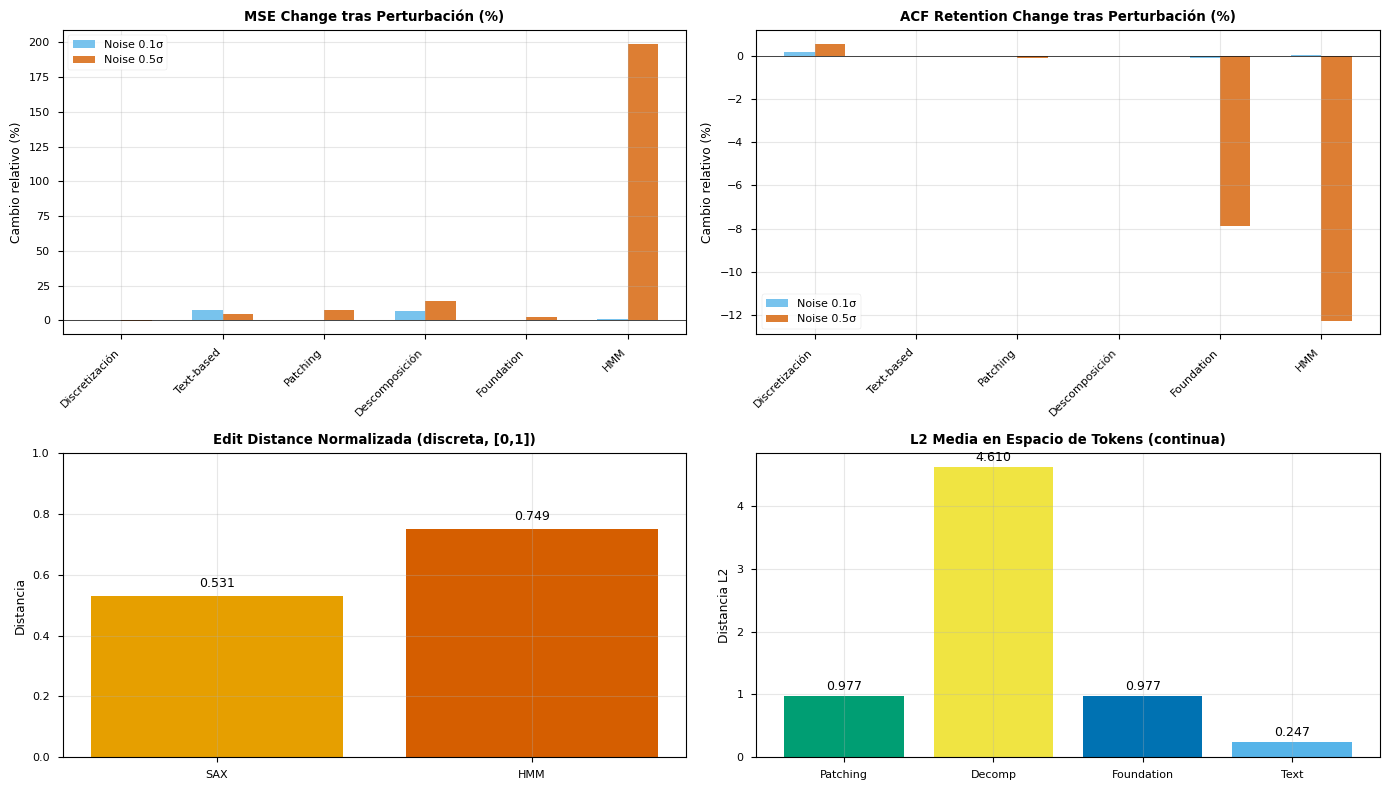

In [11]:
# Visualización de robustez
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00']
nombres = list(robustez.keys())
x = np.arange(len(nombres))

# [0,0] Perturbation stability: MSE change por nivel
ax = axes[0, 0]
mse_01 = [robustez[n]['by_level'][0.1]['mse_change_rel'] * 100 for n in nombres]
mse_05 = [robustez[n]['by_level'][0.5]['mse_change_rel'] * 100 for n in nombres]
ax.bar(x - 0.15, mse_01, 0.3, label='Noise 0.1σ', color='#56B4E9', alpha=0.8)
ax.bar(x + 0.15, mse_05, 0.3, label='Noise 0.5σ', color='#D55E00', alpha=0.8)
ax.set_title('MSE Change tras Perturbación (%)', fontweight='bold')
ax.set_ylabel('Cambio relativo (%)')
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3)

# [0,1] Perturbation stability: ACF change por nivel
ax = axes[0, 1]
acf_01 = [robustez[n]['by_level'][0.1]['acf_change_rel'] * 100 for n in nombres]
acf_05 = [robustez[n]['by_level'][0.5]['acf_change_rel'] * 100 for n in nombres]
ax.bar(x - 0.15, acf_01, 0.3, label='Noise 0.1σ', color='#56B4E9', alpha=0.8)
ax.bar(x + 0.15, acf_05, 0.3, label='Noise 0.5σ', color='#D55E00', alpha=0.8)
ax.set_title('ACF Retention Change tras Perturbación (%)', fontweight='bold')
ax.set_ylabel('Cambio relativo (%)')
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3)

# [1,0] Token distance DISCRETA (edit distance normalizada [0,1])
ax = axes[1, 0]
disc_nombres = ['SAX', 'HMM']
disc_valores = [ed_sax, ed_hmm]
disc_colors = ['#E69F00', '#D55E00']
bars = ax.bar(disc_nombres, disc_valores, color=disc_colors)
ax.set_title('Edit Distance Normalizada (discreta, [0,1])', fontweight='bold')
ax.set_ylabel('Distancia')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
for bar, val in zip(bars, disc_valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# [1,1] Token distance CONTINUA (L2 media)
ax = axes[1, 1]
cont_nombres = ['Patching', 'Decomp', 'Foundation', 'Text']
cont_valores = [l2_patch, l2_decomp, l2_found, l2_text]
cont_colors = ['#009E73', '#F0E442', '#0072B2', '#56B4E9']
bars = ax.bar(cont_nombres, cont_valores, color=cont_colors)
ax.set_title('L2 Media en Espacio de Tokens (continua)', fontweight='bold')
ax.set_ylabel('Distancia L2')
ax.grid(alpha=0.3)
for bar, val in zip(bars, cont_valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/metricas_robustez.png')
plt.show()